# **TASK 1: The Fingerprint**

---

This is the EDA phase of the assignment. I usually despise EDA because it can be a rabbit hole, but after Task 0, I feel that I will have fun with this one.

Please note that approximately 45% of Class 3 paragraphs were generated by `gemini-2.5-flash` rather than `gemini-3.1-flash-lite-preview` due to Google API's server-side errors. This mixed-model composition may contribute to observed patterns, as disclosed in the data limitations section of the Task 0 notebook.

### **Imports and Setup**

In [20]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import textstat
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import umap
from scipy import stats

np.random.seed(42) # Setting the random seed here for reproducibility

# Loading spaCy's English model 
nlp = spacy.load("en_core_web_sm")

# Data loading function
def load_jsonl(filepath):
    records = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return records

# Loading training data only
train_records = load_jsonl('../data/splits/train.jsonl')

# Grouping by label for easier analysis
class1_texts = [r['text'] for r in train_records if r['label'] == 0]  # Original novels (Human)
class2_texts = [r['text'] for r in train_records if r['label'] == 1]  # Generic AI
class3_texts = [r['text'] for r in train_records if r['label'] == 2]  # Mimic AI (Mary Shelley style)

print(f"Class 1 (Human): {len(class1_texts)} samples")
print(f"Class 2 (Generic AI): {len(class2_texts)} samples")
print(f"Class 3 (Mimic AI): {len(class3_texts)} samples")

Class 1 (Human): 350 samples
Class 2 (Generic AI): 350 samples
Class 3 (Mimic AI): 349 samples


**Why am I using only the training split for task 1?**

If I include test and validation data in my EDA, compute stats on them, and then use those insights to engineer features, I would be indirectly leaking information from the test set into my feature engineering process. 

In Task 2, I will train a classifier on those features, and the model will have seen the test set twice (once in EDA and once during evaluation). This breaks the first principle of machine learning that test data must remain completely unseen until final evaluation.

The training split is large enough (70% of total 1500 samples = 1050 samples) to give statistically sound results. I will compute all the features on train data and validate my findings with visualization and significance tests. Finally, in Task 2, I will apply the same feature pipeline to test data for evaluation.

---

### **Feature 1: Type-Token Ratio (TTR) and Moving Average TTR (MATTR)**

TTR measures the diversity of vocabulary in a text. It is computed as the ratio of the vocabulary size to the text length, i.e., `TTR = (number of unique words) / (total number of words)`. 

A higher TTR means that the author uses more unique words relative to total words. Humans, especially Victorian authors like Shelley and Dickens in our case, use a richer and more varied vocabulary. [[1]](https://www.sketchengine.eu/glossary/type-token-ratio-ttr/) 

An LLM generated generic text will tend to cycle through common words, hence a lower TTR. However, an LLM prompted to mimic a specific style (in our case, Shelley's) may attempt to use a more varied vocabulary. So, I am expecting it to have a TTR higher than the generic AI but lower than the human class. [[2]](https://pmc.ncbi.nlm.nih.gov/articles/PMC12942112/)

Therefore, I am expecting the following relationship after calculating TTR for all three classes: `TTR(Class 1) > TTR(Class 3) > TTR(Class 2)`

While reading about TTR on the internet, I came across an interesting paper: "Cutting the Gordian Knot: The Moving-Average Type-Token Ratio (MATTR)" by Covington & McFall (2010). 

Covington and McFall discuss that TTR suffers from a major flaw: it shrinks as text length increases. The paper mentions: "The longer the text goes on, the more likely it is that the next word will be one that has already occurred".

To solve this problem, they propose MATTR (Moving Average Type-Token Ratio). Instead of calculating TTR on the entire text, MATTR slides a fixed-size window across the text, computes TTR in each window, and then averages those TTR values. This is a "measure of the lexical diversity of the entire text and is not
affected by text length nor by any statistical assumptions". [[3]](https://diyhpl.us/~nmz787/pdf/Cutting_the_Gordian_Knot_The_Moving-Average_TypeToken_Ratio_MATTR.pdf)

Hence, I will compute both TTR and MATTR for all three classes with a window size of 50 words (the standard window size of 100 words is too large for short texts). I expect the same relationship for MATTR as well: `MATTR(Class 1) > MATTR(Class 3) > MATTR(Class 2)`.

**[EDIT]:** The results are surprising and counterintuitive.

In [21]:
# Type-Token Ratio (TTR) and Moving Average Type-Token Ratio (MATTR) 

def compute_ttr(text):
    words = re.findall(r'\b[a-z]+\b', text.lower()) # Extracting words, ignoring case and punctuation
    if not words:
        return 0.0 # Since TTR is a ratio, if there are no words, I will return 0.0 to avoid division by zero
    return len(set(words)) / len(words)

def compute_mattr(text, window=50):
    words = re.findall(r'\b[a-z]+\b', text.lower())
    
    if len(words) < window:
        # Falling back to raw TTR if text is shorter than the window size
        return len(set(words)) / len(words) if words else 0.0
    
    ttrs = [] # List of TTR values for each window
    # Sliding the window across the word sequence
    for i in range(len(words) - window + 1):
        chunk = words[i:i + window] # Getting the current window of words
        window_ttr = len(set(chunk)) / window # Computing the TTR of the current window
        ttrs.append(window_ttr)
    
    return np.mean(ttrs)


# Computing TTR and MATTR for each paragraph in each class
print("TTR and MATTR:")

class1 = [{'ttr': compute_ttr(text), 'mattr': compute_mattr(text, window=50)} for text in class1_texts]
class2 = [{'ttr': compute_ttr(text), 'mattr': compute_mattr(text, window=50)} for text in class2_texts]
class3 = [{'ttr': compute_ttr(text), 'mattr': compute_mattr(text, window=50)} for text in class3_texts]

# Extract means for summary statistics
ttr_mean_c1, mattr_mean_c1 = np.mean([entry['ttr'] for entry in class1]), np.mean([entry['mattr'] for entry in class1])
ttr_mean_c2, mattr_mean_c2 = np.mean([entry['ttr'] for entry in class2]), np.mean([entry['mattr'] for entry in class2])
ttr_mean_c3, mattr_mean_c3 = np.mean([entry['ttr'] for entry in class3]), np.mean([entry['mattr'] for entry in class3])

print(f"\nClass 1 (Human):")
print(f"  TTR mean: {ttr_mean_c1:.4f}")
print(f"  MATTR mean: {mattr_mean_c1:.4f}")

print(f"\nClass 2 (Generic AI):")
print(f"  TTR mean: {ttr_mean_c2:.4f}")
print(f"  MATTR mean: {mattr_mean_c2:.4f}")

print(f"\nClass 3 (Mimic AI):")
print(f"  TTR mean: {ttr_mean_c3:.4f}")
print(f"  MATTR mean: {mattr_mean_c3:.4f}")

# Storing for visualization later
lexical_richness_data = {
    'class1': [entry['mattr'] for entry in class1],
    'class2': [entry['mattr'] for entry in class2],
    'class3': [entry['mattr'] for entry in class3]
}

TTR and MATTR:

Class 1 (Human):
  TTR mean: 0.6172
  MATTR mean: 0.7966

Class 2 (Generic AI):
  TTR mean: 0.7152
  MATTR mean: 0.8327

Class 3 (Mimic AI):
  TTR mean: 0.7018
  MATTR mean: 0.8115


**What happened??**

**MATTR results (window=50): Class 1 = 0.797, Class 2 = 0.833, Class 3 = 0.812.**

[As I mentioned earlier, the trends of MATTR and TTR are expected to be the same since the former is just a moving average of the latter. ]

I expected Class 1 to have the highest MATTR, but it is actually the lowest. Surprisingly, Class 2 has the highest MATTR. But Class 3 is in between the two, which was expected.

The expectation that "humans have higher TTR than AI" holds at corpus scale, i.e., thousands of words. But my paragraphs are just 150-200 words long. This means, generic AI shows higher **local vocabulary diversity**. [[2]](https://pmc.ncbi.nlm.nih.gov/articles/PMC12942112/) [[4]](https://skylineacademic.com/blog/ai-content-detection-vs-human-review-what-really-works-in-2025/)

I recall that something like this was taught in my LLMs course that language models are trained to avoid local repetition. Our Victorian proses rely heavily on repeated dialogue tags ("said", "replied"), character names, connective phrases ("and then", "and so"). Within a 50-word window, these repetitions bring the MATTR down for Class 1. [[5]](https://www.youtube.com/playlist?list=PLxlkzujLkmQ9vMaqfvqyfvZV_o8EqjAk7)

Class 2 scored between the two classes because I think the style prompt somewhat recovered human-like repetition patterns. Class 3's local vocabulary diversity is genuinely higher than Class 1, probably because the model's training penalized local repetition.

**Conclusion:**

This suggests that MATTR at paragraph scale will be a weak feature for Tier A classification in Task 2, but it will still be included in the feature matrix. Hapax Legomena might be a better lexical richness measure for distinguishing human vs AI text but it can't be included in the feature matrix because it is a corpus-level feature. Hence, it only serves as an exploratory evidence of vocabulary diversity differences between the classes.

---

### **Feature 2: Lexical Richness - Hapax Legomena**

A hapax legomenon is a word that appears exactly once in a corpus. A higer count means a more diverse vocabulary.

Victorian authors like Shelley and Dickens deliberately used rare and complex vocabulary to create mood and literary effect. [[6]](https://www.goodreads.com/topic/show/19181214-adjusting-to-victorian-writing-style-language) 

[Gehrmann et al. (2019)](https://arxiv.org/pdf/1906.04043) showed in the *GLTR paper* that "human-written text contains words a language model considers *unlikely* significantly more often than AI-generated text." They claim that real text used words outside the model's top-100 predictions 2.41 times more frequently than generated text, even compared to sampling with a lower temperature (Section 4, Figure 4). Since hapax words are by definition rare, I think they should follow the same pattern. [[7]]((https://arxiv.org/pdf/1906.04043))

I think Class 1 (Generic AI) will use common, high-frequency words because they are most probable in the model's training data. Class 2 however, may use rarer vocabulary but will probably not be able to fully match original Shelley work.

Unlike MATTR, hapax detection will require looking at word frequencies across the whole corpus, i.e., all the records in a class. A 160-word paragraph will have almost all words appearing once by chance, making 
this metric meaningless at that scale. Therefore, I will pool all the paragraphs of a class into one corpus and compute hapax rate across the first 5000 words. [[8]](https://catswhisker.xyz/log/2017/9/7/a_first_excercise_in_natural_language_processing_with_python_counting_hapaxes/)

**Expected Order:** `Hapax(Class 1) > Hapax(Class 3) > Hapax(Class 2)`

**Note:** GLTR's metric (word rank under a language model) and hapax legomena are related but not the same.

<br>

**[EDIT]:** The results were counterintuitive, again.

In [22]:
# Feature 2: Hapax Legomena

def compute_hapax_rate(texts, sample_size=5000): # 5000 words is the conventional sample size for hapax comparison across corpora
    # Pooling all words from all paragraphs into a single list
    all_words = []
    for text in texts:
        # Extracting words in lowercase (letters only)
        words = re.findall(r'\b[a-z]+\b', text.lower())
        all_words.extend(words)
    
    # Taking only the first sample_size words
    sample = all_words[:sample_size]
    
    # Counting word frequencies in the sample
    freq = Counter(sample)
    
    # Counting words that appear exactly once
    hapax_count = sum(1 for word, count in freq.items() if count == 1)
    
    # Calculating the hapax rate (hapax words / total words in sample)
    hapax_rate = hapax_count / len(sample) if len(sample) > 0 else 0.0
    
    return hapax_count, hapax_rate

# Calling the function for each class
hapax_c1_count, hapax_c1_rate = compute_hapax_rate(class1_texts, sample_size=5000)
hapax_c2_count, hapax_c2_rate = compute_hapax_rate(class2_texts, sample_size=5000)
hapax_c3_count, hapax_c3_rate = compute_hapax_rate(class3_texts, sample_size=5000)

print(f"\nClass 1 (Human):")
print(f"  Hapax count: {hapax_c1_count}")
print(f"  Hapax rate: {hapax_c1_rate:.4f} ({hapax_c1_rate*100:.2f}% of the sample)")

print(f"\nClass 2 (Generic AI):")
print(f"  Hapax count: {hapax_c2_count}")
print(f"  Hapax rate: {hapax_c2_rate:.4f} ({hapax_c2_rate*100:.2f}% of the sample)")

print(f"\nClass 3 (Mimic AI):")
print(f"  Hapax count: {hapax_c3_count}")
print(f"  Hapax rate: {hapax_c3_rate:.4f} ({hapax_c3_rate*100:.2f}% of the sample)")

# Storing results for later comparison
hapax_results = {
    'class1': {'count': hapax_c1_count, 'rate': hapax_c1_rate},
    'class2': {'count': hapax_c2_count, 'rate': hapax_c2_rate},
    'class3': {'count': hapax_c3_count, 'rate': hapax_c3_rate}
}


Class 1 (Human):
  Hapax count: 988
  Hapax rate: 0.1976 (19.76% of the sample)

Class 2 (Generic AI):
  Hapax count: 1132
  Hapax rate: 0.2264 (22.64% of the sample)

Class 3 (Mimic AI):
  Hapax count: 1010
  Hapax rate: 0.2020 (20.20% of the sample)


**My Observation:**

At 5000 words, my GLTR-based hypothesis failed. Generic AI showed the *highest* hapax rate (22.64%), followed by Mimic AI (20.20%) and original Human content (19.76%).

This is similar to what I observed with MATTR. At small sample sizes, AI paragraphs apparently show higher diversity, probably because **each paragraph is generated independently**. AI (especially the generic one) uses synonyms and varied vocabulary across paragraphs, but within a paragraph, it avoids repetition. Human novel paragraphs share character names and dialogue tags, which reduce hapax rate within a small sample window.

This means I have to increase the corpus scale to make some genuine conclusion.

### **Hapax Legomena (Second attempt)**

According to my above rationale, hapax rates should be in line with my earlier proposed order as the sample size grows.

I will now use sample sizes of 5000 (previous), 20000, 50000, and the full corpus.

In [23]:
# Feature 2: Hapax Legomena (Second attempt)

def compute_hapax_rate(texts, sample_size):
    # Pooling all words from all paragraphs into a single list
    all_words = []
    for text in texts:
        # Extracting words in lowercase (letters only)
        words = re.findall(r'\b[a-z]+\b', text.lower())
        all_words.extend(words)
    
    # Taking only the first sample_size words
    sample = all_words[:sample_size]
    
    # Counting word frequencies in the sample
    freq = Counter(sample)
    
    # Counting words that appear exactly once
    hapax_count = sum(1 for word, count in freq.items() if count == 1)
    
    # Calculating the hapax rate (hapax words / total words in sample)
    hapax_rate = hapax_count / len(sample) if len(sample) > 0 else 0.0
    
    return hapax_count, hapax_rate

# Trying multiple sample sizes 
for sample_size in [5000, 20000, 50000, 'all']:
    if sample_size == 'all':
        n = None # Using the whole corpus
    else:
        n = sample_size
    
    results = {} 
    for class_name, texts in [('Class 1 (Human)', class1_texts), 
                              ('Class 2 (Generic AI)', class2_texts), 
                              ('Class 3 (Mimic AI)', class3_texts)]:
        all_words = []
        for text in texts: # Extracting words in lowercase (letters only)
            all_words.extend(re.findall(r'\b[a-z]+\b', text.lower()))
        sample = all_words[:n] if n else all_words # Using the whole corpus if n is None
        freq = Counter(sample)
        hapax_rate = sum(1 for c in freq.values() if c == 1) / len(sample) # hapax rate = (number of hapax words) / (total words in sample)
        results[class_name] = hapax_rate
    
    print(f"\nSample size: {sample_size if sample_size != 'all' else len(all_words)}")
    for class_name, rate in results.items():
        print(f"  {class_name}: {rate:.4f} ({rate*100:.2f}% of the sample)")


Sample size: 5000
  Class 1 (Human): 0.1976 (19.76% of the sample)
  Class 2 (Generic AI): 0.2264 (22.64% of the sample)
  Class 3 (Mimic AI): 0.2020 (20.20% of the sample)

Sample size: 20000
  Class 1 (Human): 0.1081 (10.81% of the sample)
  Class 2 (Generic AI): 0.0975 (9.75% of the sample)
  Class 3 (Mimic AI): 0.0858 (8.58% of the sample)

Sample size: 50000
  Class 1 (Human): 0.0618 (6.18% of the sample)
  Class 2 (Generic AI): 0.0475 (4.75% of the sample)
  Class 3 (Mimic AI): 0.0441 (4.41% of the sample)

Sample size: 55934
  Class 1 (Human): 0.0529 (5.29% of the sample)
  Class 2 (Generic AI): 0.0449 (4.49% of the sample)
  Class 3 (Mimic AI): 0.0413 (4.13% of the sample)


**Observations:**

At full corpus scale, the original novel texts have the highest hapax rate (5.29%).

However, in the higher scale samples, Mimic AI showed the lowest hapax rate, which is opposite to my earlier hypothesis. 
I guess the style prompt forced theme-based repetition, i.e., Gemini might have felt forced to use more Gothic vocabulary (like "wretched", "desolate", "sublime"). 

Generic AI, without any style constraints, varied its phrasing more freely, hence, it got a higher hapax rate than Mimic AI. 

Thus, the revised order at larger sample sizes is: `Hapax(Class 1) > Hapax(Class 2) > Hapax(Class 3)`

**Conclusion:**

Even though my hypothesis did not exactly pass, I can still conclude that the human-generated texts have a wider vocabulary diversity at corpus scale than AI generated ones, which is in line with the GLTR paper's findings.

As discussed earlier, I will not add Hapax Legomena to the per-paragraph feature matrix, but it has helped me confirm vocabulary diversity differences between the classes. 

--- 

### **Feature 3: Syntactic Complexity - POS Distribution**

I am trying to measure the grammatical composition of text by counting adjectives, adverbs, nouns, and verbs. These can help us compute metrics for detecting stylistic patterns that distinguish human from AI writing. 

For example, the assignment document asks an interesting question that I have observed in my daily usage of LLMs: "Does the AI "over-describe" compared to the Human?" With the help of `adjective-noun ratio`, we can empirically test this claim.

**Some metrics worth considering:**

- *Adjective-Noun ratio*: AI models (especially generic ones) usually over-describe. They use more adjectives per noun in an attempt to be more "complete".

- *Adverb density*: The number of adverbs per 100 words. Language models often load text with adverbs like "importantly", "interestingly", "notably", etc. 

- *Past tense verbs ratio:* Shelley's *Frankenstein* and Dickens's *Great Expectations* are both written in the past tense narrative. Generic AI may majorly use present tense since it matches the training data of a lot of language models. Style-mimicking AI, if the prompt is working, should follow Shelley's style and write in past tense.

- *Noun density*: The number of nouns per 100 words. It is a general measure of how "dense" the text is with entities. [[9]](https://www.vocabulary-matters.org/lexical-density) [[10]](https://aclanthology.org/2026.eacl-demo.28.pdf) [[11]](https://blog.greenflux.us/text-analysis-without-ai-lexical-density-string-similarity-readability-other-metrics/) [[12]](https://www.nltk.org/book/ch05.html) [[13]](https://www.geeksforgeeks.org/nlp/nlp-part-of-speech-default-tagging/)

**My plan:**

For each paragraph, I will use SpaCy's POS tagger to:
- Extract all tokens and filter out spaces and punctuation
- Count POS categories: nouns [proper and common], adjectives, adverbs, and verbs
- Compute the above-mentioned metrics

**My expectations:**

- *Adj-noun ratio:* Class 2 > Class 3 > Class 1
- *Adverb density:* Class 2 should have more adverbs per 100 words than Class 1
- *Past verb ratio:* Class 1 and Class 3 should be high and Class 2 might be lower
- *Noun density:* Should be relatively stable across classes

In [24]:
# FEATURE 3: PART-OF-SPEECH (POS) DISTRIBUTION

def compute_pos_features(text):
    # Parsing the paragraph to get POS tags
    doc = nlp(text)
    
    # Counting total non-space tokens for density calculations
    total_tokens = len([token for token in doc if not token.is_space])
    
    # Counting POS categories (excluding spaces and punctuation)
    pos_counts = Counter(token.pos_ for token in doc if not token.is_space and not token.is_punct)
    
    # Extracting specific counts
    # NOUN = common nouns, PROPN = proper nouns
    noun_count = pos_counts.get('NOUN', 0) + pos_counts.get('PROPN', 0)
    adj_count = pos_counts.get('ADJ', 0)
    adv_count = pos_counts.get('ADV', 0)
    verb_count = pos_counts.get('VERB', 0)
    
    # Analyze verb tense using the VBD tag for past tense
    past_verbs = sum(1 for token in doc if token.tag_ == 'VBD')
    
    # Computing the four ratios
    return {
        'adj_noun_ratio': adj_count / noun_count if noun_count > 0 else 0.0,
        'adv_per_100': (adv_count / total_tokens * 100) if total_tokens > 0 else 0.0,
        'past_tense_ratio': past_verbs / verb_count if verb_count > 0 else 0.0,
        'noun_density': noun_count / total_tokens if total_tokens > 0 else 0.0,
    }

print("Part-of-Speech features for all paragraphs:")

# Processing every paragraph in each class and extracting the POS features
pos_features_c1 = [compute_pos_features(text) for text in class1_texts]
pos_features_c2 = [compute_pos_features(text) for text in class2_texts]
pos_features_c3 = [compute_pos_features(text) for text in class3_texts]

# Helper function
def summarize_pos_metrics(features_list, class_name):
    if not features_list:
        print(f"{class_name}: No data available")
        return
    
    metrics = ['adj_noun_ratio', 'adv_per_100', 'past_tense_ratio', 'noun_density']
    print(f"\n{class_name}:")
    
    for metric in metrics: # Extracting all values for these metrics across the paragraphs
        values = [features[metric] for features in features_list]
        mean_val = np.mean(values) # Averaging over all paragraphs in the class to get a single representative value
        std_val = np.std(values) # Standard deviation will help us understand the variability within the class
        print(f"  {metric:20s}: mean = {mean_val:.4f},  std = {std_val:.4f}")

summarize_pos_metrics(pos_features_c1, "Class 1 (Human)")
summarize_pos_metrics(pos_features_c2, "Class 2 (Generic AI)")
summarize_pos_metrics(pos_features_c3, "Class 3 (Mimic AI)")

# Storing for later visualizations
pos_data = {
    'class1': pos_features_c1,
    'class2': pos_features_c2,
    'class3': pos_features_c3
}

Part-of-Speech features for all paragraphs:

Class 1 (Human):
  adj_noun_ratio      : mean = 0.3398,  std = 0.1322
  adv_per_100         : mean = 4.6391,  std = 1.6715
  past_tense_ratio    : mean = 0.5805,  std = 0.2193
  noun_density        : mean = 0.1688,  std = 0.0325

Class 2 (Generic AI):
  adj_noun_ratio      : mean = 0.4518,  std = 0.1132
  adv_per_100         : mean = 4.2277,  std = 1.6671
  past_tense_ratio    : mean = 0.0701,  std = 0.1423
  noun_density        : mean = 0.2230,  std = 0.0252

Class 3 (Mimic AI):
  adj_noun_ratio      : mean = 0.5139,  std = 0.1395
  adv_per_100         : mean = 3.6507,  std = 1.7044
  past_tense_ratio    : mean = 0.0976,  std = 0.1407
  noun_density        : mean = 0.2188,  std = 0.0184


**Observations:**

*Adjective-Noun Ratio:*

The adj-noun ratio is higher for for both the AI classes than the human class. However, I expected Mimic AI to have a lower adj-noun ratio than Generic AI but it is actually higher. This might be due to the fact that Gemini obliged to the style prompt and used excessive adjectives to mimic Shelley's gothic writing style. 

Also, as discussed at the beginning of the notebook, the multi-model composition of Class 3 (45% Gemini 2.5 and 55% Gemini 3.1) might have contributed to this unexpected result. 

*Adverb Density:*

This is also opposite of what I expected. Human text has the highest adverb density, followed by Generic AI and then Mimic AI. This might be because Victorian proses use a lot of adverbs to create a dramatic effect.

Also, I came up with the hypothesis because I have seen AI overuse common adverbs like "importantly", "interestingly", "notably" in my daily usage. But these are just a small subset of all the adverbs. Maybe the Victorian authors genuinely used a lot of adverbs in their writing. 

*Past Tense Ratio:*

I expected both Class 1 and Class 3 to have a high past verb ratio, and it turns out that Class 1 has a dramatic 58% past verb ratio. However, Class 3 and Class 2 have comparable past verb ratios (around 8%). 

I knew in the back of my mind that LMs are trained on a lot of present tense web text, but I thought the style prompt would have at least done something for Class 3. But it turns out both AI classes are strongly biased towards present tense.

*Noun Density:*

Both AI classes have a higher noun density than the human class. Maybe AI names, categorizes and describes things more explicitly whereas human writings use more of pronouns and rely on context. A small observation, but it might be worth exploring further. 

---

### **Feature 4: Syntactic Complexity - Dependency Tree Depth**

A dependency parsing tree is "a visual representation of the grammatical structure of a sentence, where words are connected based on their syntactic relationships." Each word (except the root) is "linked to a “head” word through a labeled directed edge." [[14]](https://web.stanford.edu/~jurafsky/slp3/19.pdf) [[15]](https://www.projectpro.io/article/dependency-parsing-in-nlp/1158)

I will use the depth of this tree to measure "how deeply nested a sentence's grammar is". In simple words, I will find the maximum distance from the root word (the main verb) to the deepest leaf node. [[16]](https://medium.com/data-science-in-your-pocket/dependency-parsing-associated-algorithms-in-nlp-96d65dd95d3e)

Simple sentences (like "He left. He was tired.") will have shallow trees whereas complex nested clauses (like "The man who, despite his reservations, had agreed to what she proposed, left.") will have deep trees.

As discussed earlier, Victorian texts used complex clauses to create atmosphere and a sense of depth. However, Generic AI will try to generate easy and simple sentences. Therefore, I expect the following relationship in terms of the dependency tree depth: `Depth(Class 1) > Depth(Class 3) > Depth(Class 2)`. [[17]](https://www.analyticsvidhya.com/blog/2021/12/dependency-parsing-in-natural-language-processing-with-examples/)

**My approach:**

I will use SpaCy's `token.head` and `token.children`. I will use a recursive approach to find the sentence root and then count nesting levels. According to SpaCy documentation and a few examples on the internet, simple sentences usually have a depth of around 2-4 levels, whereas complex sentences can have depths of 6-10 levels or more. [[18]](levelup.gitconnected.com/nlp-sentence-dissection-by-dependency-parsing-with-spacy-c2f54ab22cbe?gi=a8c62713f5a4) [[19]](https://spacy.io/usage/linguistic-features)

In [ ]:
# FEATURE 4: DEPENDENCY TREE DEPTH

def compute_subtree_depth(token):
    # Recursively computing the depth of a token's subtree in the dependency tree
    # Each token can have children (tokens that depend on it). Depth is the maximum nesting level below this token
    
    children = list(token.children)
    if not children:
        # Leaf node (no children), so depth is 0. Base case
        return 0
    # Recursive case: 1 + the deepest child subtree
    return 1 + max(compute_subtree_depth(child) for child in children)


def compute_tree_depth(text):
    # Computing mean dependency tree depth across all the sentences in a paragraph
    # Finding the root of each sentence and measuring how deep its tree is. Then averaging the depths across all sentences
    doc = nlp(text) 
    depths = []
    
    # Processing each sentence separately
    for sent in doc.sents:
        # Finding the root token, i.e., the one that is its own head (self-loop in the dependency graph)
        roots = [token for token in sent if token.head == token]
        
        if roots:
            # Taking the first root (should usually be exactly one)
            root = roots[0]
            depth = compute_subtree_depth(root)
            depths.append(depth)
    
    return np.mean(depths) if depths else 0.0


print("Computing dependency tree depth for all paragraphs:")

# Processing every paragraph in each class
tree_depth_c1 = [compute_tree_depth(text) for text in class1_texts]
tree_depth_c2 = [compute_tree_depth(text) for text in class2_texts]
tree_depth_c3 = [compute_tree_depth(text) for text in class3_texts]

# Computing means and standard deviations for summary
mean_depth_c1 = np.mean(tree_depth_c1)
std_depth_c1 = np.std(tree_depth_c1)
mean_depth_c2 = np.mean(tree_depth_c2)
std_depth_c2 = np.std(tree_depth_c2)
mean_depth_c3 = np.mean(tree_depth_c3)
std_depth_c3 = np.std(tree_depth_c3)

print(f"\nClass 1 (Human):")
print(f"  Mean tree depth: {mean_depth_c1:.4f}")
print(f"  Std dev:        {std_depth_c1:.4f}")

print(f"\nClass 2 (Generic AI):")
print(f"  Mean tree depth: {mean_depth_c2:.4f}")
print(f"  Std dev:        {std_depth_c2:.4f}")

print(f"\nClass 3 (Mimic AI):")
print(f"  Mean tree depth: {mean_depth_c3:.4f}")
print(f"  Std dev:        {std_depth_c3:.4f}")

# Storing for visualization and statistical tests later
tree_depth_data = {
    'class1': tree_depth_c1,
    'class2': tree_depth_c2,
    'class3': tree_depth_c3
}

Computing dependency tree depth for all paragraphs:

Class 1 (Human):
  Mean tree depth: 5.8159
  Std dev:        1.3335

Class 2 (Generic AI):
  Mean tree depth: 7.0475
  Std dev:        0.7956

Class 3 (Mimic AI):
  Mean tree depth: 8.5643
  Std dev:        1.1773


**What went wrong!?**

My hypothesis failed, again. Class 3 achieved the highest mean depth, followed by Class 2 and Class 1. 

The style prompt I fed Gemini for Class 3 data generation explicitly asked for "long, complex sentences with nested subordinate clauses." I think Gemini took this literally and generated syntactically complex sentences with deep dependency trees. SpaCy's dependency parser was able to parse these correctly because despite trying to mimic Victorian style, general-purpose LMs can't deviate much from their core training in Modern English.

Similarly, SpaCy's dependency parser is trained on large modern English corpora like the 'OntoNotes5 corpus' and 'Universal Dependencies treebanks'. These datasets are focused on late 20th and early 21st centuries, therefore Class 1's unfamiliar structure might have forced the parser to generate deep and messier parse trees out of confusion. [[20]](https://github.com/explosion/spaCy/discussions/8645) [[21]](https://stackoverflow.com/a/40288324/19652721) [[22]](https://spacy.io/api/dependencyparser) [[23]](https://medium.com/@akhtarhaniya/spacys-dependencyparser-what-goes-on-behind-the-scenes-e2fc2d8b5f6a) 

I think a dataset like *The Corpus of Late Modern English Texts (CLMET)* would have been a better corpus to train the dependency parser on for specialized Victorian English parsing. [[24]](https://icame.info/icame_static/ij29/ij29-page69-82.pdf) 

Generic AI prompt seems to have produced varied sentence lengths, more than a simple prose but less than  explicitly prompted complexity. Hence, it came in between the two classes.

**Standard Deviation Observation:**

Human std (1.33) is the highest of all the three classes. This means human paragraphs vary a lot in sentence complexity. When I skimmed through Class 1 data, I saw that Dickens' scenes seemed to have less complexity than Shelley's.

AI classes have lower standard deviations which mean they use more uniform sentence structures. 

This feature will probably hurt Tier A classification in Task 2 because it points in the wrong direction. I will see later if I drop it or not.

---

### **Feature 5: Punctuation Density**

I am excited for this step because punctuation reflects the author's writing conventions. Different classes of text usually exhibit punctuation differently based on writing style and requirements.

For example, Victorian authors like Shelley and Dickens used a variety of punctuation marks to create emphasis and rhythm. These include semicolons, em-dashes, colons, and exclamation marks. 

On the other hand, language models trained on web text usually rely on simpler punctuation patterns. In my daily use, I have observed that LLMs often overuse commas, periods, quotation marks, etc.

Some punctuation rates that I feel are worth looking at are: semicolon, comma, colon, emdash, exclamation and question mark. [[25]](https://medium.com/@LauraHKahn/nlp-punctuation-lower-case-and-stopwords-pre-processing-d4888c4da940) [[26]](https://levelup.gitconnected.com/from-words-to-numbers-a-deep-dive-into-nlp-feature-engineering-1cdf83c817df)

I expect that Class 1 will significantly outperform the AI classes in terms of **semicolon and em-dash usage** because LLMs avoid complex punctuation. The former will also outperform the latter in terms of **exclamation mark and question mark usage** but not by a margin as large as the previous one.

For **comma usage**, I am sure that it will be high across all classes, but AI might rely on it more heavily because it is a "safe" connector. But it is also possible that the comma rate might be similar across classes.

**My approach:**

I will compute the frequency of the above-mentioned punctuation marks per 1000 words for each paragraph and normalize it. This relative punctuation rate will help compare the punctuation usage patterns across classes.

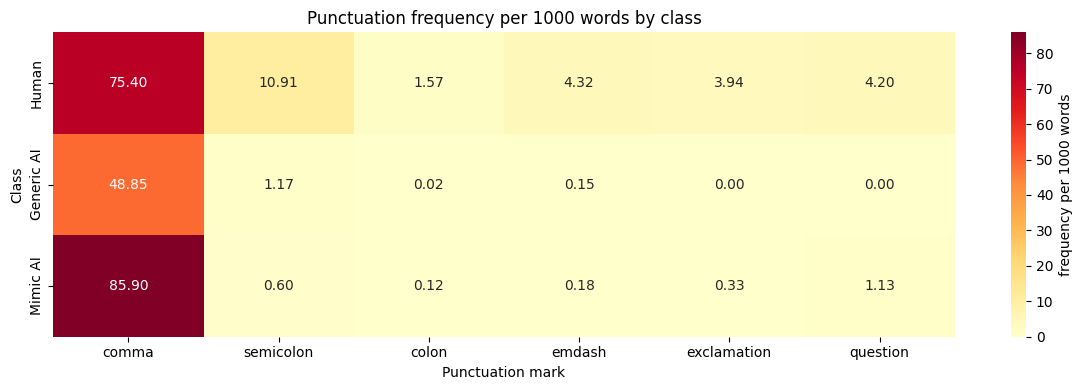

Mean punctuation rates (per 1000 words):

Class 1 (Human):
  comma_rate          : 75.40
  semicolon_rate      : 10.91
  colon_rate          : 1.57
  emdash_rate         : 4.32
  exclamation_rate    : 3.94
  question_rate       : 4.20

Class 2 (Generic AI):
  comma_rate          : 48.85
  semicolon_rate      : 1.17
  colon_rate          : 0.02
  emdash_rate         : 0.15
  exclamation_rate    : 0.00
  question_rate       : 0.00

Class 3 (Mimic AI):
  comma_rate          : 85.90
  semicolon_rate      : 0.60
  colon_rate          : 0.12
  emdash_rate         : 0.18
  exclamation_rate    : 0.33
  question_rate       : 1.13


In [ ]:
# FEATURE 5: PUNCTUATION DENSITY AND HEATMAP
import os

def compute_punctuation_features(text):
    # Counting specific punctuation marks and normalizing per 1000 words
    # This will allow us to compare punctuation usage across texts of different lengths
    
    word_count = len(text.split())
    scale = 1000 / word_count if word_count > 0 else 0
    
    return {
        'comma_rate': text.count(',') * scale,
        'semicolon_rate': text.count(';') * scale,
        'colon_rate': text.count(':') * scale,
        'emdash_rate': (text.count('\u2014') + text.count('--')) * scale,
        'exclamation_rate': text.count('!') * scale,
        'question_rate': text.count('?') * scale
    }

# Processing every paragraph in each class
punc_features_c1 = [compute_punctuation_features(text) for text in class1_texts]
punc_features_c2 = [compute_punctuation_features(text) for text in class2_texts]
punc_features_c3 = [compute_punctuation_features(text) for text in class3_texts]

# Storing all punctuation features for later use
punc_data = {
    'class1': punc_features_c1,
    'class2': punc_features_c2,
    'class3': punc_features_c3
}

# Building the mean matrix for heatmap visualization
punc_feature_names = ['comma_rate', 'semicolon_rate', 'colon_rate', 'emdash_rate', 
                      'exclamation_rate', 'question_rate']

# Computing class-level means for each punctuation type
mean_matrix = np.array([
    [np.mean([f[p] for f in punc_features_c1]) for p in punc_feature_names],
    [np.mean([f[p] for f in punc_features_c2]) for p in punc_feature_names],
    [np.mean([f[p] for f in punc_features_c3]) for p in punc_feature_names],
])

# Creating the heatmap
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    mean_matrix,
    annot=True, fmt='.2f',
    xticklabels=[p.replace('_rate', '') for p in punc_feature_names],
    yticklabels=['Human', 'Generic AI', 'Mimic AI'],
    cmap='YlOrRd', ax=ax, cbar_kws={'label': 'frequency per 1000 words'}
)
ax.set_title('Punctuation frequency per 1000 words by class')
ax.set_ylabel('Class')
ax.set_xlabel('Punctuation mark')
plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'task1', 'punctuation heatmap.png'))
plt.show()

print("Mean punctuation rates (per 1000 words):")
for idx, class_name in enumerate(['Class 1 (Human)', 'Class 2 (Generic AI)', 'Class 3 (Mimic AI)']):
    print(f"\n{class_name}:")
    for feat_idx, feat_name in enumerate(punc_feature_names):
        print(f"  {feat_name:20s}: {mean_matrix[idx, feat_idx]:.2f}")

**Observations:**

My hypothesis for *semi-colon* and *em-dash* usage was correct. There is a 10x jump from Class 2 and an 18x jump from Class 3 to Class 1 in semi-colon usage. Em-dash shows a similar pattern. As I mentioned above, Victorian authors used these marks to create rhythm within long sentences. Neither the Generic AI nor the Mimic AI could replicate this pattern.
This is by far the most distinctive feature between human and AI text in my EDA.

*Generic AI zeroes* for exclamation mark, question mark and parantheses show that a neutrally prompted LLM reflects the training data distribution where commas, periods and quotation marks are more common.

*Comma rate* is a surprise for me. Mimic AI  has the highest (85.90) rate which means Gemini tried to write complex Victorian sentences by merging clauses with commas because it doesn't use semicolons. It achieved some syntactic complexity (previous feature) but used the "safe" commas whereas a human writer like Shelley would have used semicolons.

In a nutshell, I can say that wherever Shelley would have used a semicolon, Gemini used a comma. Funny.

---

### **Feature 6: Readability Indices - Flesch-Kincaid Grade Level**

The **Flesch-Kincaid Grade Level (FK Grade)** is a widely used English readability formula. "It assesses the approximate reading grade level of a text, based on average sentence length and word complexity. It produces scores corresponding to US grade levels, which are roughly equivalent to someone’s number of years of education." [[27]](https://readable.com/readability/flesch-reading-ease-flesch-kincaid-grade-level/)

`FK GRADE = 0.39 * (total words / total sentences) + 11.8 * (total syllables / total words) - 15.59`

Reading ease and grade level will be important features to assess how difficult a text is to read. A score of 12-15 means that the text requires a college-level education to understand comfortably. This will be informative for this task because Victorian proses are complex and challenging whereas AI-generated text use simpler sentence structures.

The **Flesch Reading Ease (FRE)** is a similar metric on a 0-100 scale with the score inversely related to the grade level. I mean to say that a higher FRE score means the text is easier to read, i.e., a lower FK Grade. [[28]](https://textinspector.com/flesch-kincaid-grade-level-a-key-tool-for-english-educators/)

**My expectations:**

I have made it obvious from the above definitions that I am expecting Class 1 to have the highest FK Grade, followed by Class 3 and then Class 2. Looking at the number of my failed hypotheses so far, I am anticipating that it will be an interesting story with both the AI classes.

Naturally, I expect Mimic AI to have a higher FK Grade than Generic AI because of my style prompt. It may not be as high as the human class, but it should exceed the Generic AI's grade level.

**Approach:**

I will calculate both FK Grade and FRE for each paragraph using the `textstat` library. I will then try to analyze the distribution of these scores across classes.

In [ ]:
# FEATURE 6: FLESCH-KINCAID GRADE AND FLESCH READING EASE

def compute_readability_features(text):
    fk_grade = textstat.flesch_kincaid_grade(text)
    reading_ease = textstat.flesch_reading_ease(text)
    
    return {
        'fk_grade': fk_grade,
        'reading_ease': reading_ease,
    }

print("Readability indices for all paragraphs:")

readability_c1 = [compute_readability_features(text) for text in class1_texts]
readability_c2 = [compute_readability_features(text) for text in class2_texts]
readability_c3 = [compute_readability_features(text) for text in class3_texts]

def summarize_readability(features_list, class_name): 
    if not features_list:
        print(f"{class_name}: No data available")
        return
    
    metrics = ['fk_grade', 'reading_ease']
    print(f"\n{class_name}:")
    
    for metric in metrics: # Calculating mean and standard deviation for each readability metric across the paragraphs in the class
        values = [features[metric] for features in features_list]
        mean_val = np.mean(values)
        std_val = np.std(values)
        print(f"  {metric:20s}: mean = {mean_val:6.2f},  std = {std_val:6.2f}")

summarize_readability(readability_c1, "Class 1 (Human)")
summarize_readability(readability_c2, "Class 2 (Generic AI)")
summarize_readability(readability_c3, "Class 3 (Mimic AI)")

readability_data = {
    'class1': readability_c1,
    'class2': readability_c2,
    'class3': readability_c3
}

Readability indices for all paragraphs:

Class 1 (Human):
  fk_grade            : mean =  10.63,  std =   4.36
  reading_ease        : mean =  64.15,  std =  13.70

Class 2 (Generic AI):
  fk_grade            : mean =  14.41,  std =   1.80
  reading_ease        : mean =  34.47,  std =  11.95

Class 3 (Mimic AI):
  fk_grade            : mean =  19.27,  std =   3.08
  reading_ease        : mean =  25.62,  std =  11.25


**Results and Observations:**

My hypothesis was partially right. I correctly predicted that the Mimic AI would have a higher FK Grade than Generic AI. But I did not expect the Human class to come last.

Two things that drive up the FK Grade are long sentences and multi-syllable words. My Class 3 prompt explicitly asked for both, "long complex sentences with nested subordinate clauses" and "formal Victorian vocabulary." It seems that Gemini followed this and produced texts with a very high FK Grade.

After seeing the human class coming in last, I think the standard deviation (4.36) highlights wide variations in Dickens and Shelley's writing styles. Dickens' scenes are easier to read which probably drove the FK Grade up but Shelley's more complex ones brought it down a lot.

Another interesting observation is that SpaCy splits sentences aggressively at semicolons and other punctuation. This might have increased the sentence count per paragraph and lowered the average sentence length, hence, directly affecting the FK Grade and FRE. [[29]](https://spacy.io/usage/linguistic-features)

Reading ease (FRE) tells the same story but just in reverse. According to this result, I can say that human class is the easist to read, followed by Generic AI and then Mimic AI. This is counterintuitive and limited to just this dataset, but it is what it is.

**Note:** The FK grade will be a useful feature in Tier A classification but with an inverted correlation to what I assumed, i.e., a higher FK grade meaning more likely AI. I will note this when I will interpret feature importance in Task 2.

---

### **Compiling the Feature Matrix**

In [33]:
feature_rows = [] # Each row corresponds to a paragraph with all its features and the label

for idx, text in enumerate(class1_texts):
    feature_rows.append({
        'label': 0,
        'text_id': idx,
        'ttr': class1[idx]['ttr'],
        'mattr': class1[idx]['mattr'],
        'adj_noun_ratio': pos_data['class1'][idx]['adj_noun_ratio'],
        'adv_per_100': pos_data['class1'][idx]['adv_per_100'],
        'past_tense_ratio': pos_data['class1'][idx]['past_tense_ratio'],
        'noun_density': pos_data['class1'][idx]['noun_density'],
        'tree_depth': tree_depth_data['class1'][idx],
        'comma_rate': punc_data['class1'][idx]['comma_rate'],
        'semicolon_rate': punc_data['class1'][idx]['semicolon_rate'],
        'colon_rate': punc_data['class1'][idx]['colon_rate'],
        'emdash_rate': punc_data['class1'][idx]['emdash_rate'],
        'exclamation_rate': punc_data['class1'][idx]['exclamation_rate'],
        'question_rate': punc_data['class1'][idx]['question_rate'],
        'fk_grade': readability_data['class1'][idx]['fk_grade'],
        'reading_ease': readability_data['class1'][idx]['reading_ease'],
    })

for idx, text in enumerate(class2_texts):
    feature_rows.append({
        'label': 1,
        'text_id': idx,
        'ttr': class2[idx]['ttr'],
        'mattr': class2[idx]['mattr'],
        'adj_noun_ratio': pos_data['class2'][idx]['adj_noun_ratio'],
        'adv_per_100': pos_data['class2'][idx]['adv_per_100'],
        'past_tense_ratio': pos_data['class2'][idx]['past_tense_ratio'],
        'noun_density': pos_data['class2'][idx]['noun_density'],
        'tree_depth': tree_depth_data['class2'][idx],
        'comma_rate': punc_data['class2'][idx]['comma_rate'],
        'semicolon_rate': punc_data['class2'][idx]['semicolon_rate'],
        'colon_rate': punc_data['class2'][idx]['colon_rate'],
        'emdash_rate': punc_data['class2'][idx]['emdash_rate'],
        'exclamation_rate': punc_data['class2'][idx]['exclamation_rate'],
        'question_rate': punc_data['class2'][idx]['question_rate'],
        'fk_grade': readability_data['class2'][idx]['fk_grade'],
        'reading_ease': readability_data['class2'][idx]['reading_ease'],
    })

for idx, text in enumerate(class3_texts):
    feature_rows.append({
        'label': 2,
        'text_id': idx,
        'ttr': class3[idx]['ttr'],
        'mattr': class3[idx]['mattr'],
        'adj_noun_ratio': pos_data['class3'][idx]['adj_noun_ratio'],
        'adv_per_100': pos_data['class3'][idx]['adv_per_100'],
        'past_tense_ratio': pos_data['class3'][idx]['past_tense_ratio'],
        'noun_density': pos_data['class3'][idx]['noun_density'],
        'tree_depth': tree_depth_data['class3'][idx],
        'comma_rate': punc_data['class3'][idx]['comma_rate'],
        'semicolon_rate': punc_data['class3'][idx]['semicolon_rate'],
        'colon_rate': punc_data['class3'][idx]['colon_rate'],
        'emdash_rate': punc_data['class3'][idx]['emdash_rate'],
        'exclamation_rate': punc_data['class3'][idx]['exclamation_rate'],
        'question_rate': punc_data['class3'][idx]['question_rate'],
        'fk_grade': readability_data['class3'][idx]['fk_grade'],
        'reading_ease': readability_data['class3'][idx]['reading_ease'],
    })

df = pd.DataFrame(feature_rows)
df.to_csv('../data/features/train_features.csv', index=False)

print(f"Feature matrix saved with {len(df)} rows and {len(df.columns)} columns")
print(f"\nShape per class:")
print(df['label'].value_counts().sort_index())

Feature matrix saved with 1049 rows and 17 columns

Shape per class:
label
0    350
1    350
2    349
Name: count, dtype: int64


### **PCA and UMAP Visualization**

Since I have 15 features per paragraph now, I want to visualize the data in 2D space to ultimately see if the features can separate the classes visually. Principal Component Analysis will help bring down the 15-dimensional feature space to 2 dimensions while trying to preserve as much variance as possible.

UMAP is meant to preserve local neighborhood structure in the data. It is a non-linear dimensionality reduction technique to capture relationships between features that PCA might miss. I am expecting it to be cleaner than PCA because of its non-linear nature. Hence, it will be able to capture more complex relationships between features and classes than PCA. [[30]](https://www.ibm.com/think/topics/principal-component-analysis) [[31]](https://www.stat.cmu.edu/~cshalizi/uADA/12/lectures/ch18.pdf) [[32]](https://umap-learn.readthedocs.io/en/latest/plotting.html)

PC1 explains 37.9% of the variance
PC2 explains 11.5% of the variance
Total: 49.4%



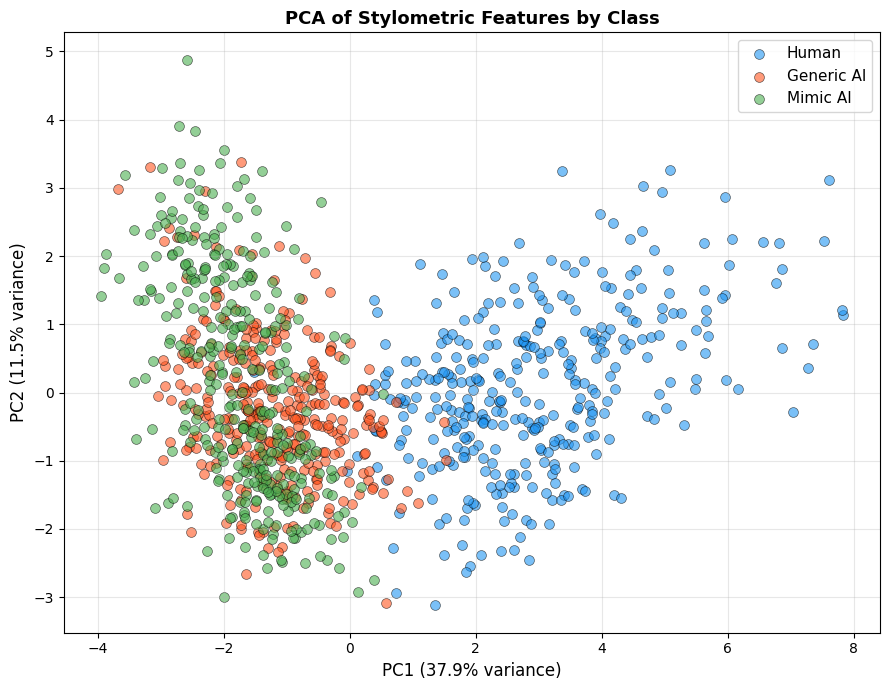

PCA Component Loadings (sorted by PC1):
                       PC1       PC2
reading_ease      0.387700 -0.097062
past_tense_ratio  0.298191  0.008717
semicolon_rate    0.247941 -0.010119
exclamation_rate  0.243307  0.173582
emdash_rate       0.222994  0.154853
question_rate     0.215126  0.155850
colon_rate        0.123963  0.059286
adv_per_100       0.076365  0.461092
comma_rate        0.036103  0.481792
mattr            -0.204024  0.392948
adj_noun_ratio   -0.220567  0.405730
tree_depth       -0.305690 -0.153316
noun_density     -0.315971 -0.278892
fk_grade         -0.339123  0.099842
ttr              -0.350752  0.182966


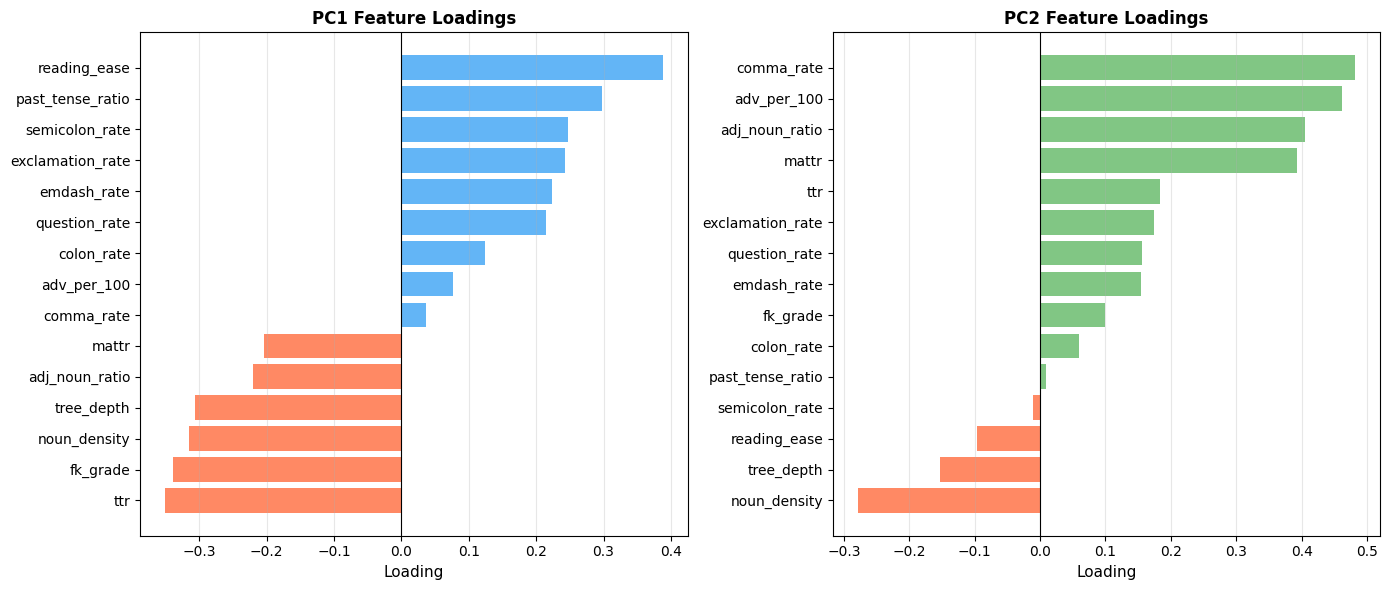

In [ ]:
# PCA VISUALIZATION

# Selecting numeric feature columns (excluding label and text_id)
feature_cols = [c for c in df.columns if c not in ('label', 'text_id')]
X = df[feature_cols].values
y = df['label'].values

# Standardizing the features before PCA (mean=0, std=1) to ensure that PCA captures real feature relationships
# Features have different scales (semicolon_rate is 5-75 but fk_grade is 10-16)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Taking the first 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of the variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of the variance")
print(f"Total: {(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])*100:.1f}%\n")

colors = {0: '#2196F3', 1: '#FF5722', 2: '#4CAF50'}
labels_str = {0: 'Human', 1: 'Generic AI', 2: 'Mimic AI'}

# Creating a scatter plot of the PCA results, x-axis is PC1 and y-axis is PC2
fig, ax = plt.subplots(figsize=(9, 7))
for label in [0, 1, 2]:
    mask = y == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[label], label=labels_str[label],
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA of Stylometric Features by Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'task1', 'pca_scatter.png'))
plt.show()

# Extracting and visualizing PCA loadings to figure out which features drive the separation
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

print("PCA Component Loadings (sorted by PC1):")
print(loadings.sort_values('PC1', ascending=False)) # Finding which features contribute most to PC1 and PC2

# Visualizing loadings as horizontal bars
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# PC1 loadings
loadings_pc1 = loadings['PC1'].sort_values()
colors_pc1 = ['#FF5722' if x < 0 else '#2196F3' for x in loadings_pc1.values]
ax1.barh(range(len(loadings_pc1)), loadings_pc1.values, color=colors_pc1, alpha=0.7) # Setting horizontal bars' transparency to 0.7 for better visibility
ax1.set_yticks(range(len(loadings_pc1)))
ax1.set_yticklabels(loadings_pc1.index, fontsize=10)
ax1.set_xlabel('Loading', fontsize=11)
ax1.set_title('PC1 Feature Loadings', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(axis='x', alpha=0.3)

# PC2 loadings
loadings_pc2 = loadings['PC2'].sort_values()
colors_pc2 = ['#FF5722' if x < 0 else '#4CAF50' for x in loadings_pc2.values]
ax2.barh(range(len(loadings_pc2)), loadings_pc2.values, color=colors_pc2, alpha=0.7)
ax2.set_yticks(range(len(loadings_pc2)))
ax2.set_yticklabels(loadings_pc2.index, fontsize=10)
ax2.set_xlabel('Loading', fontsize=11)
ax2.set_title('PC2 Feature Loadings', fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'task1', 'pca_loadings.png'))
plt.show()

Computing UMAP on all stylometric features...
----------------------------------------------------------------------


d:\Precog-Recruitment-Task\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


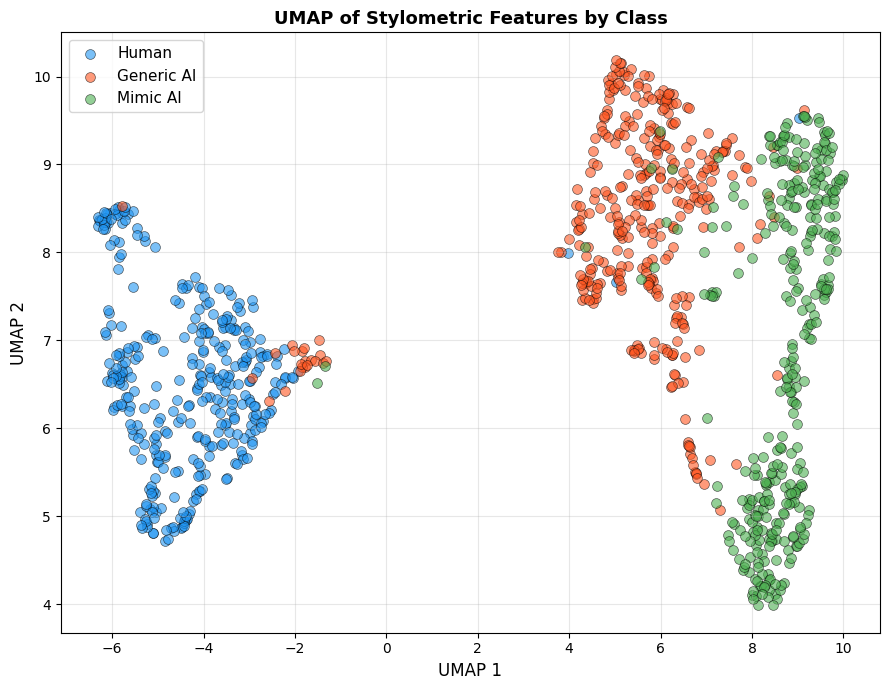

In [ ]:
# UMAP VISUALIZATION

print("Computing UMAP on all stylometric features...")
print("-" * 70)

# Fitting UMAP to 2 dimensions with 15 neighbors and a minimum distance of 0.1.
# With this config, UMAP will try to preserve local structure (within 15 nearest neighbors). It will allow 0.1 minimum distance between clusters
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)

# Plotting the UMAP scatter
fig, ax = plt.subplots(figsize=(9, 7))
for label in [0, 1, 2]:
    mask = y == label
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=colors[label], label=labels_str[label],
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('UMAP of Stylometric Features by Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'task1', 'umap_scatter.png'))
plt.show()

**Results and Interpretations:**

PCA compressed 15 stylometric features into two principal components capturing 49.4% of the total variance (PC1: 37.9%, PC2: 11.5%), i.e., PC1 captures 37.9% of the original 15-dimensional feature space and PC2 captures 11.5%. This is almost half of the variance in the data, which is not great but enough to see the real structure. 

**PC1 (Human v/s AI axis)**

PC1 separated Human from both AI classes with some boundary cases. Every Human paragraph sits on the positive side of PC1 and almost all of the AI paragraphs on the negative side, with a few exceptions. The features that drive this separation are:

*Human Characteristics (Positive Loadings):* `reading_ease`, `past_tense_ratio`, `semicolon_rate`, `exclamation_rate`, `emdash_rate`. These are the features where Victorian texts differ from the AI-generated ones. (in terms of punctuation, tense, and sentence structure)

*AI Characteristics (Negative Loadings):* `TTR`, `FK Grade`, `noun density`, `tree_depth`, `adj-noun ratio`. These are the features where my hypotheses reversed, i.e., AI scored higher on all of them. The negative loadings confirm that the reversals were real and consistent, and not just noise. Higher FK grade, higher 
noun density, and deeper parse trees proved to be the AI goveaways in this dataset. (even though they are counterintuitive).

**PC2 (Generic AI v/s Mimic AI axis)**

PC2 axis gave a partial separation between the two AI classes, but they overlap a lot. Comma rate, adverb density, and adj-noun ratio push towards Generic AI while tree depth and noun density pull towards Mimic AI. The separation is weak because the two AI classes are similar on many features.

**UMAP Analysis**

UMAP preserved local neighbourhood structure and the result is striking. All three classes formed distinct clusters with minimal overlap. Human text is completely isolated on the left while Generic AI and Mimic AI are adjacent but distinguishable clusters on the right. 

I can infer something important from the UMAP and PCA: the stylometric features that I computed are quite discriminative, i.e., the classes are separable. UMAP especially shows that the classifiers I will train in Task 2 should be fine in this 15-dimensional feature space.

The catch will be the boundary between Generic AI and Mimic AI. The few orange and green points scattered near the Human cluster in UMAP are the AI paragraphs where Gemini closely mimicked human style.


### **Conclusion**

After computing 15 stylometric features across 1050 training paragraphs, I can conclude that **the three classes are mathematically distinct**. However, the fingerprints of these classes (the 15 features) are not what I initially expected.

The punctuation analysis was the cleanest finding in this entire notebook. Semicolons and em-dashes appear 10-18x more frequently in human text than in AI text. Human text dominated on past-tense verb ratio (58%) while both AI classes were at 8%. 

I have prepared the 15-dimensional feature matrix for Task 2, where I will use it to train three tiers of classifiers.



### **References for EDA**

**AI and Tool Usage**

The analytical framing for PCA and UMAP visualization like "what to expect" and "how to interpret" was inspired by [DeepSeek's Reasoning LLM](https://www.deepseek.com/en/) and supported by my own study of IBM's article, CMU's lecture pdf, and the UMAP documentation. I used the LLM as a discussion partner to test my reasoning before writing it into this notebook. The hypotheses and observations in the MD cells are my own conclusions after looking at the outputs, informed by that discussion. [[33]](https://www.deepseek.com/en/)

For code, GitHub Copilot assisted with the SpaCy pipeline and the matplotlib visualization cells. I wrote the feature extraction functions (MATTR, punctuation density, FK Grade, etc.) myself based on the approaches described in the cited sources. Copilot was helpful in suggesting code snippets and syntax for the Dependency Tree Depth calculation, PCA and UMAP visualizations, but the logic and code structure was mine.
I also used a research assistance hub, [Bohrium AI](https://www.bohrium.com/en), to locate the relevant sections of [Gehrmann et al. (2019)](https://arxiv.org/pdf/1906.04043) without reading the full paper. This saved me a lot of time. [[34]](https://www.bohrium.com/en)

1. Glossary: Type-Token Ratio (TTR). Sketch Engine. https://www.sketchengine.eu/glossary/type-token-ratio-ttr/

2. Human vs. LLM Creativity: A Comparative Analysis of Task-Dependent Asymmetry and Linguistic Features. PMC. https://pmc.ncbi.nlm.nih.gov/articles/PMC12942112/

3. Covington, M. A., & McFall, J. D. (2010). Cutting the Gordian Knot: The Moving-Average Type–Token Ratio (MATTR). Journal of Quantitative Linguistics, 17(2), 94–100. https://doi.org/10.1080/09296171003643098

4. AI Content Detection vs Human Review: What Really Works in 2025? Skyline Academic. https://skylineacademic.com/blog/ai-content-detection-vs-human-review-what-really-works-in-2025/

5. Large Language Models (LLMs) Course. Dr. Kshitiz Verma. https://www.youtube.com/playlist?list=PLxlkzujLkmQ9vMaqfvqyfvZV_o8EqjAk7

6. "Adjusting to Victorian Writing Style & Language". Goodreads. https://www.goodreads.com/topic/show/19181214-adjusting-to-victorian-writing-style-language

7. Sebastian Gehrmann, Hendrik Strobelt, and Alexander Rush. 2019. GLTR: Statistical Detection and Visualization of Generated Text. https://arxiv.org/pdf/1906.04043

8. A first excercise in natural language processing with Python: counting hapaxes. Catswhisker. https://catswhisker.xyz/log/2017/9/7/a_first_excercise_in_natural_language_processing_with_python_counting_hapaxes/

9. Lexical Density. Vocabulary Matters. https://www.vocabulary-matters.org/lexical-density

10. Section 2.1 of "PUCP Matrix: An Open-source and Comprehensive Toolkit for Linguistic Analysis of Spanish Texts". EACL 2026. https://aclanthology.org/2026.eacl-demo.28.pdf

11. Text Analysis without AI: Lexical Density, String Similarity, Readability, Other Metrics. Greenflux Blog. https://blog.greenflux.us/text-analysis-without-ai-lexical-density-string-similarity-readability-other-metrics/

12. Chapter 5: Categorizing and Tagging Words. NLTK Book. https://www.nltk.org/book/ch05.html

13. NLP Part of Speech Default Tagging. GeeksforGeeks. https://www.geeksforgeeks.org/nlp/nlp-part-of-speech-default-tagging/

14. "19. Dependency Parsing". Stanford NLP Course. https://web.stanford.edu/~jurafsky/slp3/19.pdf

15. "Dependency Parsing in NLP". ProjectPro. https://www.projectpro.io/article/dependency-parsing-in-nlp/1158

16. "Dependency Parsing: Associated Algorithms in NLP". Medium. https://medium.com/data-science-in-your-pocket/dependency-parsing-associated-algorithms-in-nlp-96d65dd95d3e

17. "Dependency Parsing in Natural Language Processing with Examples". Analytics Vidhya. https://www.analyticsvidhya.com/blog/2021/12/dependency-parsing-in-natural-language-processing-with-examples/

18. "NLP Sentence Dissection by Dependency Parsing with SpaCy". LevelUp. https://levelup.gitconnected.com/nlp-sentence-dissection-by-dependency-parsing-with-spacy-c2f54ab22cbe?gi=a8c62713f5a4

19. "Linguistic Features". SpaCy Documentation. https://spacy.io/usage/linguistic-features

20. SpaCy Dependency Parser Discussion. GitHub. https://github.com/explosion/spaCy/discussions/8645

21. StackOverflow: Why does SpaCy's dependency parser produce deep trees for simple sentences? https://stackoverflow.com/a/40288324/19652721

22. SpaCy API: DependencyParser. https://spacy.io/api/dependencyparser

23. "SpaCy's DependencyParser: What Goes on Behind the Scenes". Medium. https://medium.com/@akhtarhaniya/spacys-dependencyparser-what-goes-on-behind-the-scenes-e2fc2d8b5f6a

24. "The Corpus of Late Modern English Texts (CLMET)". ICAME. https://icame.info/icame_static/ij29/ij29-page69-82.pdf

25. "NLP Punctuation, Lower Case, and Stopwords Pre-processing". Medium. https://medium.com/@LauraHKahn/nlp-punctuation-lower-case-and-stopwords-pre-processing-d4888c4da940

26. "From Words to Numbers: A Deep Dive into NLP Feature Engineering". LevelUp. https://levelup.gitconnected.com/from-words-to-numbers-a-deep-dive-into-nlp-feature-engineering-1cdf83c817df

27. "Flesch Reading Ease & Flesch-Kincaid Grade Level". Readable. https://readable.com/readability/flesch-reading-ease-flesch-kincaid-grade-level/

28. "Flesch-Kincaid Grade Level: A Key Tool for English Educators". Text Inspector. https://textinspector.com/flesch-kincaid-grade-level-a-key-tool-for-english-educators/

29. Linguistic Features. SpaCy Documentation. https://spacy.io/usage/linguistic-features

30. "Principal Component Analysis". IBM. https://www.ibm.com/think/topics/principal-component-analysis

31. "Lecture 18: Principal Component Analysis". CMU Statistics. https://www.stat.cmu.edu/~cshalizi/uADA/12/lectures/ch18.pdf

32. "UMAP Plotting". UMAP Learn Documentation. https://umap-learn.readthedocs.io/en/latest/plotting.html

33. DeepSeek. https://www.deepseek.com/en/

34. Bohrium AI. https://www.bohrium.com/en